              precision    recall  f1-score   support

        High       0.89      0.89      0.89         9
         Low       0.95      0.95      0.95        22
      Medium       0.78      0.78      0.78         9

    accuracy                           0.90        40
   macro avg       0.87      0.87      0.87        40
weighted avg       0.90      0.90      0.90        40



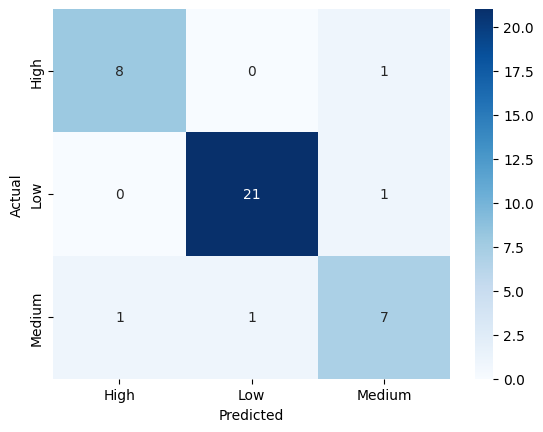

['demand_label_encoder.pkl']

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel("product_demand.xlsx")

# Encode labels
label_encoder = LabelEncoder()
df['demand_label_encoded'] = label_encoder.fit_transform(df['demand_label'])

X = df[['trend_score', 'competition_score', 'price_range']]
y = df['demand_label_encoded']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model artifacts
joblib.dump(model, "demand_model.pkl")
joblib.dump(scaler, "demand_scaler.pkl")
joblib.dump(label_encoder, "demand_label_encoder.pkl")

In [2]:
# Load trained model
model = joblib.load("demand_model.pkl")
scaler = joblib.load("demand_scaler.pkl")
label_encoder = joblib.load("demand_label_encoder.pkl")

# Simulate backend input
backend_input = {"trend_score": 70, "competition_score": 55, "price_range": 40}

sample = pd.DataFrame([[backend_input['trend_score'],
                        backend_input['competition_score'],
                        backend_input['price_range']]],
                      columns=['trend_score','competition_score','price_range'])

sample_scaled = scaler.transform(sample)

# Predict label
prediction = model.predict(sample_scaled)
pred_label = label_encoder.inverse_transform(prediction)

# Predict confidence
proba = model.predict_proba(sample_scaled)
confidence = np.max(proba)

print("Predicted Demand:", pred_label[0])
print("Confidence Score:", round(confidence, 2))

Predicted Demand: Medium
Confidence Score: 0.62
